['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


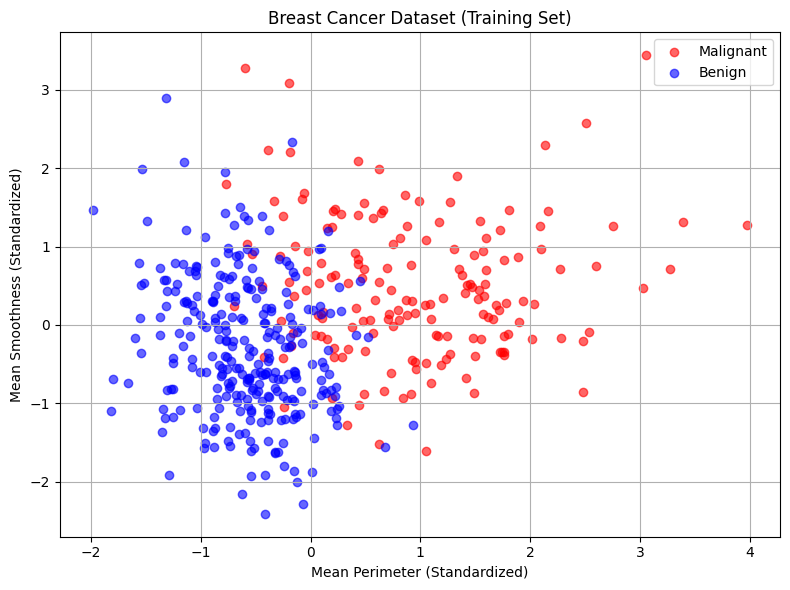

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

# --------------------------------------------------
# Load dataset
data = load_breast_cancer()

# Features & labels
X = data.data
y = data.target

# Print feature names
print(data.feature_names)

# --------------------------------------------------
# Select two features:
# 2 -> mean perimeter
# 4 -> mean smoothness
X = X[:, [2, 4]]

# --------------------------------------------------
# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# --------------------------------------------------
# Add bias term (for custom models later)
X = np.hstack((X, np.ones((X.shape[0], 1))))

# --------------------------------------------------
# Train / Validation split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Plot training data
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    color="red",
    alpha=0.6,
    label="Malignant"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color="blue",
    alpha=0.6,
    label="Benign"
)

plt.xlabel("Mean Perimeter (Standardized)")
plt.ylabel("Mean Smoothness (Standardized)")
plt.title("Breast Cancer Dataset (Training Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
# -----------------------------
# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# -----------------------------
# Binary cross-entropy loss
def compute_loss(w, X, y):
    z = X @ w
    preds = sigmoid(z)

    # avoid log(0)
    eps = 1e-9
    preds = np.clip(preds, eps, 1 - eps)

    loss = -np.mean(y * np.log(preds) + (1 - y) * np.log(1 - preds))
    return loss


# -----------------------------
# Gradient of loss
def compute_gradient(w, X, y):
    preds = sigmoid(X @ w)
    errors = preds - y
    grad = (X.T @ errors) / len(y)
    return grad


# -----------------------------
# Validation accuracy
def validation_accuracy(w, X_val, y_val):
    probs = sigmoid(X_val @ w)
    preds = (probs >= 0.5).astype(int)
    return np.mean(preds == y_val)


# -----------------------------
# Gradient Descent training
def gradient_descent_logistic(
        X_train, y_train,
        X_val, y_val,
        learning_rate=0.1,
        n_steps=1000,
        tolerance=1e-6):

    # initialize weights
    w = np.zeros(X_train.shape[1])

    # history tracking
    loss_history = [compute_loss(w, X_train, y_train)]
    val_accuracy_history = [validation_accuracy(w, X_val, y_val)]
    weights_history = [w.copy()]

    for step in range(1, n_steps + 1):

        # compute gradient
        grad = compute_gradient(w, X_train, y_train)

        # update weights
        w -= learning_rate * grad

        # compute metrics
        loss = compute_loss(w, X_train, y_train)
        acc = validation_accuracy(w, X_val, y_val)

        loss_history.append(loss)
        val_accuracy_history.append(acc)

        # save weights every 10 steps
        if step % 10 == 0:
            weights_history.append(w.copy())

        # convergence check
        if abs(loss_history[-2] - loss_history[-1]) < tolerance:
            print(f'Converged at step {step}')
            break

        # progress log
        if step % 100 == 0:
            print(f'Step {step}: Loss={loss:.4f}, Val Acc={acc:.4f}')

    return w, loss_history, val_accuracy_history, weights_history


In [8]:
# -----------------------------
# Training settings
learning_rate = 0.05
n_steps = 800

# Train model
w_opt, loss_history, val_accuracy_history, weights_history = gradient_descent_logistic(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=learning_rate,
    n_steps=n_steps
)

# -----------------------------
# Results
print(f'Optimized weights: {w_opt}')

print(
    f'Decision rule: '
    f'{w_opt[0]:.3f} * Mean Perimeter + '
    f'{w_opt[1]:.3f} * Mean Smoothness + '
    f'{w_opt[2]:.3f} > 0  →  Benign'
)

print(
    f'Decision rule: '
    f'{w_opt[0]:.3f} * Mean Perimeter + '
    f'{w_opt[1]:.3f} * Mean Smoothness + '
    f'{w_opt[2]:.3f} < 0  →  Malignant'
)


Step 100: Loss = 0.3581, Validation Accuracy = 0.8860
Step 200: Loss = 0.2903, Validation Accuracy = 0.8860
Step 300: Loss = 0.2615, Validation Accuracy = 0.8860
Step 400: Loss = 0.2455, Validation Accuracy = 0.8860
Step 500: Loss = 0.2353, Validation Accuracy = 0.8860
Step 600: Loss = 0.2283, Validation Accuracy = 0.8860
Step 700: Loss = 0.2232, Validation Accuracy = 0.8860
Step 800: Loss = 0.2193, Validation Accuracy = 0.8860
Optimized weights: [-2.91812905 -1.07565575  0.59294996]
Decision rule: -2.918 * Mean Perimeter + -1.076 * Mean Smoothness + 0.593 > 0  →  Benign
Decision rule: -2.918 * Mean Perimeter + -1.076 * Mean Smoothness + 0.593 < 0  →  Malignant


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24148\3913014356.py:13: RuntimeWarning: invalid value encountered in scalar divide
  plt.axvline(x=-w[2] / w[0], color='green')


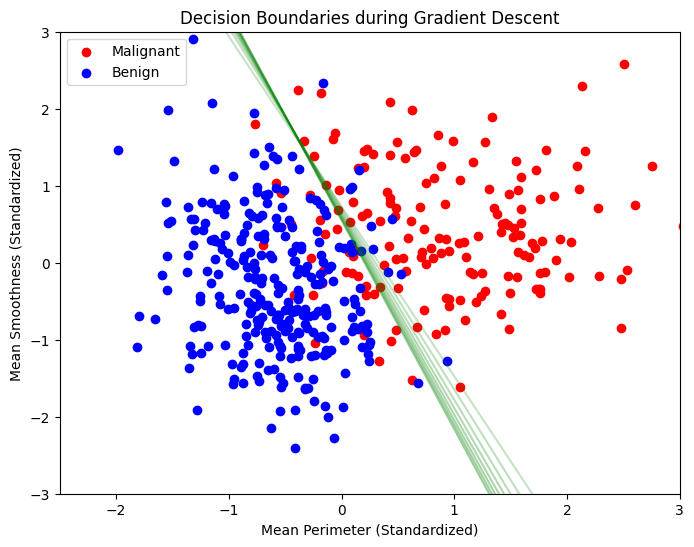

In [9]:
# Plot a single decision boundary for given weights
def plot_decision_boundary(w, X, y, step, total_steps):
    x_values = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])

    # Compute corresponding y-values for the boundary
    if w[1] != 0:
        y_values = -(w[0] * x_values + w[2]) / w[1]
        # Draw boundary with increasing opacity over steps
        plt.plot(x_values, y_values, color='green',
                 alpha=(0.20 + (step / total_steps) * 0.20))
    else:
        # Vertical line if w[1] == 0
        plt.axvline(x=-w[2] / w[0], color='green')

    plt.legend()


# Plot all decision boundaries throughout training
def plot_decision_boundaries(weights_history, X, y, total_steps):

    plt.figure(figsize=(8, 6))

    # Plot data points by class
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Malignant')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Benign')

    # Set plot limits
    plt.xlim(-2.5, 3)
    plt.ylim(-3, 3)

    # Plot decision boundaries for selected training steps
    for i, w in enumerate(weights_history):
        if i % 10 == 0:
            step = i * 10
            plot_decision_boundary(w, X, y, step, total_steps)

    plt.title('Decision Boundaries during Gradient Descent')
    plt.xlabel('Mean Perimeter (Standardized)')
    plt.ylabel('Mean Smoothness (Standardized)')
    plt.show()


plot_decision_boundaries(weights_history, X_train[:, :2], y_train, n_steps)

              precision    recall  f1-score     support
Malignant      0.837209  0.857143  0.847059   42.000000
Benign         0.915493  0.902778  0.909091   72.000000
accuracy       0.885965  0.885965  0.885965    0.885965
macro avg      0.876351  0.879960  0.878075  114.000000
weighted avg   0.886652  0.885965  0.886237  114.000000
Accuracy: 0.8860


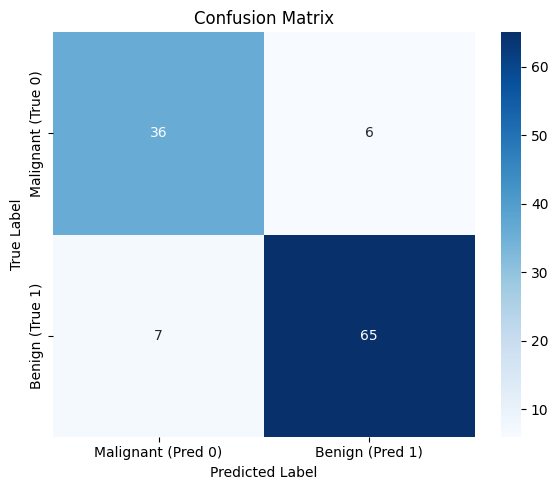

ROC Curve Analysis
AUC: 0.9613


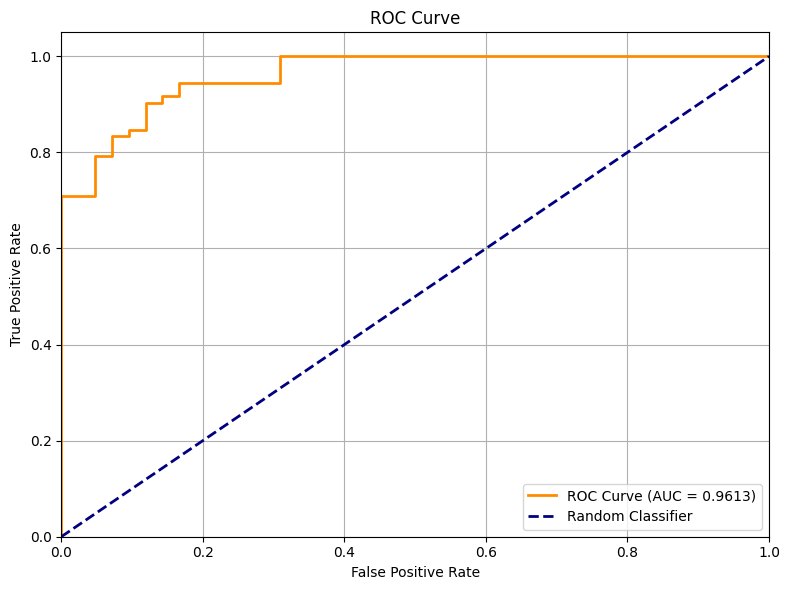

In [11]:
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import pandas as pd

# --------------------------------------------------
# Model probabilities and predictions
prob_val = sigmoid(X_val @ w_opt)
pred_val = (prob_val >= 0.5).astype(int)

# --------------------------------------------------
# Classification report
report = classification_report(
    y_val,
    pred_val,
    target_names=['Malignant', 'Benign'],
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
print(df_report)

# Overall accuracy
accuracy = report["accuracy"]
print(f"Accuracy: {accuracy:.4f}")

# --------------------------------------------------
# Confusion matrix
cm = confusion_matrix(y_val, pred_val)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant (Pred 0)', 'Benign (Pred 1)'],
    yticklabels=['Malignant (True 0)', 'Benign (True 1)']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# ROC curve + AUC
fpr, tpr, _ = roc_curve(y_val, prob_val)
roc_auc = auc(fpr, tpr)

print("ROC Curve Analysis")
print(f"AUC: {roc_auc:.4f}")

# --------------------------------------------------
# Plot ROC
plt.figure(figsize=(8,6))

plt.plot(
    fpr, tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1], [0,1],
    linestyle="--",
    color="navy",
    lw=2,
    label="Random Classifier"
)

plt.xlim(0,1)
plt.ylim(0,1.05)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


**Breast Cancer Classification**


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

None

****************************************************************************************************


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


label
1    357
0    212
Name: count, dtype: int64
Missing values in y_train: 0
Missing values in y_test: 0
Unique labels: [0 1]
Accuracy on training data = 0.989010989010989
Accuracy on test data = 0.9824561403508771


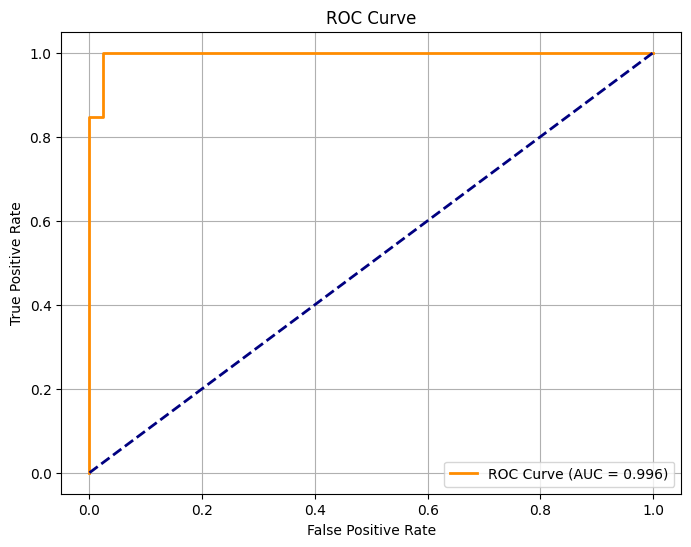

In [14]:
import numpy as np
import pandas as pd
import sklearn.datasets
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# Load dataset
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

data_frame = pd.DataFrame(
    breast_cancer_dataset.data,
    columns=breast_cancer_dataset.feature_names
)

# Add label column
data_frame["label"] = breast_cancer_dataset.target

display(data_frame)

# --------------------------------------------------
# Basic dataset info
print(data_frame.shape)
display(data_frame.info())

print("*" * 100)

display(data_frame.isnull().sum())  # check missing values
display(data_frame.describe())      # statistical summary

print(data_frame["label"].value_counts())

# --------------------------------------------------
# Features and labels
X = data_frame.drop(columns="label", axis=1)
Y = data_frame["label"]

# Train / Test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2,
    stratify=Y
)

# --------------------------------------------------
# Check labels
print("Missing values in y_train:", Y_train.isnull().sum())
print("Missing values in y_test:", Y_test.isnull().sum())
print("Unique labels:", Y_train.unique())

# --------------------------------------------------
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, Y_train)

# --------------------------------------------------
# Training accuracy
train_pred = model.predict(X_train_scaled)
training_data_accuracy = accuracy_score(Y_train, train_pred)

print("Accuracy on training data =", training_data_accuracy)

# Test accuracy
test_pred = model.predict(X_test_scaled)
test_data_accuracy = accuracy_score(Y_test, test_pred)

print("Accuracy on test data =", test_data_accuracy)

# --------------------------------------------------
# ROC curve (use probabilities)
test_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(Y_test, test_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(8,6))

plt.plot(
    fpr, tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot([0,1], [0,1], linestyle="--", color="navy", lw=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()
